In [6]:
import random
import math

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import roc_auc_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

In [7]:
## GENERATOR


BRACKET_PAIRS = [("(", ")"), ("[", "]"), ("{", "}")]


def is_correct_bracket_sequence(seq):
    stack = []

    opening = "([{"
    closing = ")]}"
    matching = {")": "(", "]": "[", "}": "{"}

    for char in seq:
        if char in opening:
            stack.append(char)

        elif char in closing:
            if len(stack) == 0:
                return False

            top = stack.pop()

            if top != matching[char]:
                return False

        else:
            raise ValueError(f"Invalid character: {char}")

    return len(stack) == 0


def get_sequence_metadata(seq):
    stack = []
    max_observed_depth = 0
    bracket_types = set()

    for char in seq:
        if char in "([{":
            stack.append(char)
            max_observed_depth = max(max_observed_depth, len(stack))

        elif char in ")]}":
            if len(stack) > 0:
                stack.pop()

        if char in "()":
            bracket_types.add("round")
        elif char in "[]":
            bracket_types.add("square")
        elif char in "{}":
            bracket_types.add("curly")

    return {
        "length": len(seq),
        "num_pairs": len(seq) // 2,
        "observed_depth": max_observed_depth,
        "num_bracket_types": len(bracket_types),
    }


def generate_valid_sequence(min_pairs=1, max_pairs=20):
    n_pairs = random.randint(min_pairs, max_pairs)

    def generate_exact(pairs):
        if pairs == 0:
            return ""

        open_b, close_b = random.choice(BRACKET_PAIRS)

        remaining_pairs = pairs - 1

        inside_pairs = random.randint(0, remaining_pairs)
        after_pairs = remaining_pairs - inside_pairs

        inside = generate_exact(inside_pairs)
        after = generate_exact(after_pairs)

        return open_b + inside + close_b + after

    return generate_exact(n_pairs)


def corrupt_sequence(seq):
    if len(seq) == 0:
        return random.choice(")]}"), "insert"

    seq = list(seq)
    corruption_type = random.choice(["delete", "replace", "insert", "swap"])

    if corruption_type == "delete":
        idx = random.randrange(len(seq))
        del seq[idx]

    elif corruption_type == "replace":
        idx = random.randrange(len(seq))
        seq[idx] = random.choice("()[]{}")

    elif corruption_type == "insert":
        idx = random.randrange(len(seq) + 1)
        seq.insert(idx, random.choice("()[]{}"))

    elif corruption_type == "swap":
        if len(seq) >= 2:
            i, j = random.sample(range(len(seq)), 2)
            seq[i], seq[j] = seq[j], seq[i]
        else:
            seq.append(random.choice(")]}"))
            corruption_type = "insert"

    corrupted = "".join(seq)
    return corrupted, corruption_type


def generate_invalid_sequence(min_pairs=1, max_pairs=20):
    while True:
        valid_seq = generate_valid_sequence(min_pairs=min_pairs, max_pairs=max_pairs)

        invalid_seq, error_type = corrupt_sequence(valid_seq)
        real_pairs = len(invalid_seq) // 2

        if (min_pairs <= real_pairs <= max_pairs and not is_correct_bracket_sequence(invalid_seq)):
            return invalid_seq, error_type


def generate_fixed_data(size, min_pairs=1, max_pairs=20, seed=42):
    random.seed(seed)
    np.random.seed(seed)

    data = []

    for idx in range(size):
        label = idx % 2

        if label == 0:
            seq = generate_valid_sequence(
                min_pairs=min_pairs,
                max_pairs=max_pairs
            )
            error_type = "valid"

        else:
            seq, error_type = generate_invalid_sequence(
                min_pairs=min_pairs,
                max_pairs=max_pairs
            )

        metadata = get_sequence_metadata(seq)
        metadata["error_type"] = error_type
        metadata["min_pairs_setting"] = min_pairs
        metadata["max_pairs_setting"] = max_pairs

        data.append((seq, label, metadata))

    random.shuffle(data)
    return data

In [8]:
## MODEL


def rotate_half(x):
    x_even = x[..., 0::2]
    x_odd = x[..., 1::2]

    return torch.stack((-x_odd, x_even), dim=-1).flatten(-2)


def apply_rope(q, k):
    _, _, seq_length, head_dim = q.shape

    if head_dim % 2 != 0:
        raise ValueError("RoPE requires an even head_dim.")

    device = q.device

    positions = torch.arange(seq_length, device=device)
    frequencies = torch.arange(0, head_dim, 2, device=device)

    inv_freq = 1.0 / (10000 ** (frequencies.float() / head_dim))
    angles = torch.outer(positions.float(), inv_freq)

    sin = angles.sin()[None, None, :, :].repeat_interleave(2, dim=-1)
    cos = angles.cos()[None, None, :, :].repeat_interleave(2, dim=-1)

    q = q * cos + rotate_half(q) * sin
    k = k * cos + rotate_half(k) * sin

    return q, k


def build_alibi_bias(nhead, seq_length, device):
    slopes = torch.tensor(
        [2 ** (-8 * (i + 1) / nhead) for i in range(nhead)],
        device=device
    )

    positions = torch.arange(seq_length, device=device)
    distance = (positions[None, :] - positions[:, None]).abs().float()

    bias = -slopes[:, None, None] * distance[None, :, :]

    return bias.unsqueeze(0)


class TransformerBlock(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward, dropout, positional_embedding):
        super().__init__()

        if d_model % nhead != 0:
            raise ValueError("d_model must be divisible by nhead.")

        self.d_model = d_model
        self.nhead = nhead
        self.head_dim = d_model // nhead
        self.positional_embedding = positional_embedding

        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.attn_out = nn.Linear(d_model, d_model)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model),
        )

        self.norm_attn = nn.LayerNorm(d_model)
        self.norm_ffn = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)


    def split_heads(self, x):
        batch_size, seq_length, _ = x.shape
        x = x.view(batch_size, seq_length, self.nhead,self.head_dim)
        return x.transpose(1, 2)


    def merge_heads(self, x):
        batch_size, _, seq_length, _ = x.shape
        x = x.transpose(1, 2).contiguous()
        return x.view(batch_size, seq_length, self.d_model)


    def attention(self, x, padding_mask):
        batch_size, seq_length, _ = x.shape

        qkv = self.qkv(x)
        q, k, v = qkv.chunk(3, dim=-1)

        q = self.split_heads(q)
        k = self.split_heads(k)
        v = self.split_heads(v)

        if self.positional_embedding == "rope":
            q, k = apply_rope(q, k)

        scores = q @ k.transpose(-2, -1)
        scores = scores / math.sqrt(self.head_dim)

        if self.positional_embedding == "alibi":
            scores = scores + build_alibi_bias(self.nhead, seq_length, x.device)

        if padding_mask is not None:
            scores = scores.masked_fill(padding_mask[:, None, None, :], float("-inf"))

        weights = F.softmax(scores, dim=-1)
        weights = self.dropout(weights)

        output = weights @ v
        output = self.merge_heads(output)

        return self.attn_out(output)


    def forward(self, x, padding_mask=None):
        x = x + self.dropout(self.attention(self.norm_attn(x), padding_mask))
        x = x + self.dropout(self.ffn(self.norm_ffn(x)))

        return x


class BracketTransformer(nn.Module):
    def __init__(
        self,
        vocab_size=8,
        seq_length=256,
        pad_id=0,
        d_model=128,
        nhead=8,
        num_layers=4,
        dim_feedforward=512,
        dropout=0.1,
        positional_embedding="absolute",
    ):
        super().__init__()

        allowed_embeddings = {"absolute", "rope", "alibi"}
        if positional_embedding not in allowed_embeddings:
            raise ValueError(
                f"positional_embedding must be one of {allowed_embeddings}."
            )

        self.pad_id = pad_id
        self.seq_length = seq_length
        self.positional_embedding = positional_embedding

        self.token_embedding = nn.Embedding(
            vocab_size,
            d_model,
            padding_idx=pad_id
        )

        self.position_embedding = (
            nn.Embedding(seq_length, d_model)
            if positional_embedding == "absolute"
            else None
        )

        self.encoder = nn.ModuleList(
            [
                TransformerBlock(
                    d_model=d_model,
                    nhead=nhead,
                    dim_feedforward=dim_feedforward,
                    dropout=dropout,
                    positional_embedding=positional_embedding,
                )
                for _ in range(num_layers)
            ]
        )

        self.head = nn.Sequential(
            nn.LayerNorm(2 * d_model),
            nn.Linear(2 * d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1)
        )

    def add_absolute_positions(self, x):
        batch_size, seq_length, _ = x.shape

        positions = torch.arange(seq_length, device=x.device)
        positions = positions.unsqueeze(0).expand(batch_size, seq_length)

        return x + self.position_embedding(positions)

    def forward(self, x):
        padding_mask = x == self.pad_id

        x = self.token_embedding(x)

        if self.positional_embedding == "absolute":
            x = self.add_absolute_positions(x)

        for block in self.encoder:
            x = block(x, padding_mask=padding_mask)

        cls_token = x[:, 0, :]

        valid_mask = (~padding_mask).float()
        valid_mask[:, 0] = 0.0

        denom = valid_mask.sum(dim=1, keepdim=True).clamp(min=1.0)
        mean_token = (x * valid_mask.unsqueeze(-1)).sum(dim=1) / denom

        pooled = torch.cat([cls_token, mean_token], dim=-1)

        logits = self.head(pooled).squeeze(1)

        return logits


def create_model(seq_length=256, positional_embedding="absolute"):
    return BracketTransformer(
        vocab_size=8,
        seq_length=seq_length,
        pad_id=PAD_ID,
        d_model=128,
        nhead=8,
        num_layers=4,
        dim_feedforward=512,
        dropout=0.1,
        positional_embedding=positional_embedding,
    )

In [9]:
## TRAIN


VOCAB = {
    "<PAD>": 0,
    "<CLS>": 1,
    "(": 2,
    ")": 3,
    "[": 4,
    "]": 5,
    "{": 6,
    "}": 7,
}

PAD_ID = VOCAB["<PAD>"]
CLS_ID = VOCAB["<CLS>"]


class BracketSequenceDataset(Dataset):
    def __init__(
        self,
        size=None,
        seq_length=256,
        train=True,
        min_pairs=1,
        max_pairs=20,
        data=None,
    ):
        self.data = data
        self.size = len(data) if data is not None else size
        self.seq_length = seq_length
        self.train = train
        self.min_pairs = min_pairs
        self.max_pairs = max_pairs

    def __len__(self):
        return self.size

    def tokenize(self, seq):
        tokens = [CLS_ID]

        for char in seq:
            tokens.append(VOCAB[char])

        if len(tokens) > self.seq_length:
            tokens = tokens[:self.seq_length]

        while len(tokens) < self.seq_length:
            tokens.append(PAD_ID)

        return np.array(tokens, dtype=np.int64)

    def __getitem__(self, idx):
        if self.data is not None:
            item = self.data[idx]

            if len(item) == 2:
                seq, label = item
            else:
                seq, label, metadata = item

        else:
            label = idx % 2

            if label == 0:
                seq = generate_valid_sequence(
                    min_pairs=self.min_pairs,
                    max_pairs=self.max_pairs
                )
            else:
                result = generate_invalid_sequence(
                    min_pairs=self.min_pairs,
                    max_pairs=self.max_pairs
                )

                if isinstance(result, tuple):
                    seq, error_type = result
                else:
                    seq = result

        x = self.tokenize(seq)

        x = torch.tensor(x, dtype=torch.long)
        y = torch.tensor(float(label), dtype=torch.float32)

        return x, y


def get_metrics(logits, labels):
    probs = torch.sigmoid(logits).cpu().numpy()
    labels = labels.cpu().numpy()

    preds = (probs >= 0.5).astype(np.float32)

    acc = (preds == labels).mean()

    try:
        auc = roc_auc_score(labels, probs)
    except ValueError:
        auc = float("nan")

    return auc, acc


@torch.no_grad()
def evaluate(model, loader, device, criterion):
    model.eval()

    losses = []
    logits_list = []
    labels_list = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        logits = logits.squeeze(-1)

        loss = criterion(logits, y)

        losses.append(loss.item())
        logits_list.append(logits.cpu())
        labels_list.append(y.cpu())

    logits = torch.cat(logits_list)
    labels = torch.cat(labels_list)

    auc, acc = get_metrics(logits, labels)

    return np.mean(losses), auc, acc


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def train(
    num_epochs=10,
    batch_size=64,
    lr=1e-3,
    train_size=30000,
    val_size=10000,
    seq_length=256,
    min_pairs=1,
    max_pairs=20,
    positional_embedding="absolute",
    checkpoint_path=None,
    train_data=None,
    val_data=None,
    seed=42,
):
    set_seed(seed)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print("Using device:", device)
    print("Positional embedding:", positional_embedding)

    if checkpoint_path is None:
        checkpoint_path = f"model_{positional_embedding}.pth"

    train_dataset = BracketSequenceDataset(
        size=train_size,
        seq_length=seq_length,
        train=True,
        min_pairs=min_pairs,
        max_pairs=max_pairs,
        data=train_data,
    )

    val_dataset = BracketSequenceDataset(
        size=val_size,
        seq_length=seq_length,
        train=False,
        min_pairs=min_pairs,
        max_pairs=max_pairs,
        data=val_data,
    )

    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=g
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    model = create_model(
        positional_embedding=positional_embedding,
        seq_length=seq_length
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    criterion = nn.BCEWithLogitsLoss()

    best_val_auc = -1.0

    for epoch in range(1, num_epochs + 1):
        model.train()

        losses = []
        logits_list = []
        labels_list = []

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            logits = model(x)
            logits = logits.squeeze(-1)

            loss = criterion(logits, y)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()

            losses.append(loss.item())
            logits_list.append(logits.detach().cpu())
            labels_list.append(y.cpu())

        train_logits = torch.cat(logits_list)
        train_labels = torch.cat(labels_list)

        train_loss = np.mean(losses)
        train_auc, train_acc = get_metrics(train_logits, train_labels)

        val_loss, val_auc, val_acc = evaluate(
            model,
            val_loader,
            device,
            criterion
        )

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            torch.save(model.state_dict(), checkpoint_path)

        print(
            f"Epoch {epoch}/{num_epochs} | "
            f"PE {positional_embedding} | "
            f"train loss {train_loss:.4f} | "
            f"train auc {train_auc:.4f} | "
            f"train acc {train_acc:.4f} | "
            f"val loss {val_loss:.4f} | "
            f"val auc {val_auc:.4f} | "
            f"val acc {val_acc:.4f}"
        )

    print(f"Best val AUC for {positional_embedding}: {best_val_auc:.4f}")

    return best_val_auc

In [10]:
def train_all_positional_embeddings():
    positional_embeddings = ["absolute", "rope", "alibi"]

    train_data = generate_fixed_data(
        size=50000,
        min_pairs=1,
        max_pairs=20,
        seed=42
    )

    val_data = generate_fixed_data(
        size=10000,
        min_pairs=1,
        max_pairs=20,
        seed=123
    )

    results = {}

    for pe in positional_embeddings:
      best_auc = train(
          num_epochs=15,
          batch_size=32,
          lr=5e-4,
          train_size=50000,
          val_size=10000,
          seq_length=256,
          min_pairs=1,
          max_pairs=20,
          positional_embedding=pe,
          checkpoint_path=f"model_{pe}.pth",
          train_data=train_data,
          val_data=val_data,
          seed=42
      )

      results[pe] = best_auc
    return results


pe_results = train_all_positional_embeddings()

Using device: cuda
Positional embedding: absolute
Epoch 1/15 | PE absolute | train loss 0.5479 | train auc 0.7643 | train acc 0.6857 | val loss 0.4485 | val auc 0.8466 | val acc 0.7820
Epoch 2/15 | PE absolute | train loss 0.3878 | train auc 0.8612 | train acc 0.8191 | val loss 0.3600 | val auc 0.8894 | val acc 0.8309
Epoch 3/15 | PE absolute | train loss 0.3364 | train auc 0.9012 | train acc 0.8556 | val loss 0.3186 | val auc 0.9159 | val acc 0.8811
Epoch 4/15 | PE absolute | train loss 0.2923 | train auc 0.9230 | train acc 0.8845 | val loss 0.2463 | val auc 0.9382 | val acc 0.9027
Epoch 5/15 | PE absolute | train loss 0.2598 | train auc 0.9376 | train acc 0.9004 | val loss 0.2224 | val auc 0.9468 | val acc 0.9174
Epoch 6/15 | PE absolute | train loss 0.2377 | train auc 0.9454 | train acc 0.9118 | val loss 0.2171 | val auc 0.9502 | val acc 0.9235
Epoch 7/15 | PE absolute | train loss 0.2189 | train auc 0.9524 | train acc 0.9195 | val loss 0.1825 | val auc 0.9600 | val acc 0.9369
Epoch

In [12]:
def collect_predictions_for_model(
    model,
    test_data,
    seq_length,
    device,
    positional_embedding,
    test_name
):
    model.eval()
    rows = []

    tokenizer_dataset = BracketSequenceDataset(
        size=1,
        seq_length=seq_length
    )

    for item in test_data:
        if len(item) == 2:
            seq, label = item
            metadata = {
                "length": len(seq),
                "num_pairs": len(seq) // 2,
                "observed_depth": None,
                "num_bracket_types": None,
                "error_type": "unknown",
            }
        else:
            seq, label, metadata = item

        x = tokenizer_dataset.tokenize(seq)
        x = torch.tensor(x, dtype=torch.long).unsqueeze(0).to(device)

        with torch.no_grad():
            logit = model(x).squeeze()
            prob = torch.sigmoid(logit).item()

        pred = int(prob >= 0.5)
        correct = int(pred == label)

        row = {
            "positional_embedding": positional_embedding,
            "test": test_name,
            "seq": seq,
            "label": label,
            "class": "valid" if label == 0 else "invalid",
            "pred": pred,
            "prob": prob,
            "correct": correct,
        }

        row.update(metadata)
        rows.append(row)

    return pd.DataFrame(rows)


def run_error_analysis(
    positional_embeddings=["absolute", "rope", "alibi"],
    seq_length=256,
    test_size=10000,
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    test_settings = [
        ("ID_10", 1, 10),
        ("ID_20", 11, 20),
        ("OOD_40", 21, 40),
        ("OOD_60", 41, 60),
        ("OOD_100", 61, 100),
    ]

    fixed_test_data = {}

    for seed_id, (test_name, min_pairs, max_pairs) in enumerate(test_settings):
        test_data = generate_fixed_data(
            size=test_size,
            min_pairs=min_pairs,
            max_pairs=max_pairs,
            seed=3000 + seed_id
        )

        fixed_test_data[test_name] = test_data

    all_predictions = []

    for pe in positional_embeddings:
        print("=" * 80)
        print(f"Error analysis for: {pe}")
        print("=" * 80)

        model = create_model(
            positional_embedding=pe,
            seq_length=seq_length
        ).to(device)

        model.load_state_dict(
            torch.load(f"model_{pe}.pth", map_location=device)
        )

        model.eval()

        for test_name, test_data in fixed_test_data.items():
            pred_df = collect_predictions_for_model(
                model=model,
                test_data=test_data,
                seq_length=seq_length,
                device=device,
                positional_embedding=pe,
                test_name=test_name
            )

            all_predictions.append(pred_df)

    error_df = pd.concat(all_predictions, ignore_index=True)

    return error_df


error_df = run_error_analysis(
    positional_embeddings=["absolute", "rope", "alibi"],
    seq_length=256,
    test_size=10000
)

error_df.head()

Error analysis for: absolute
Error analysis for: rope
Error analysis for: alibi


,positional_embedding,test,seq,label,class,pred,prob,correct,length,num_pairs,observed_depth,num_bracket_types,error_type,min_pairs_setting,max_pairs_setting
0,absolute,ID_10,((())(()))[[][]],0,valid,0,0.049399,1,16,8,3,2,valid,1,10
1,absolute,ID_10,]((()[])){}(()[]),1,invalid,1,1.000000,1,17,8,3,3,insert,1,10
2,absolute,ID_10,{{{{)}}}}{{}}[],1,invalid,1,1.000000,1,15,7,4,3,insert,1,10
3,absolute,ID_10,([])[,1,invalid,1,1.000000,1,5,2,2,2,insert,1,10
4,absolute,ID_10,([]()]{})[(())],1,invalid,1,1.000000,1,15,7,3,3,insert,1,10


In [13]:
TRAIN_MAX_PAIRS = 20

test_order = ["ID_10", "ID_20", "OOD_40", "OOD_60", "OOD_100"]

test_to_max_pairs = {
    "ID_10": 10,
    "ID_20": 20,
    "OOD_40": 40,
    "OOD_60": 60,
    "OOD_100": 100,
}


def rgb_string_to_tuple(color):
    if isinstance(color, str) and color.startswith("rgb"):
        values = color[color.find("(") + 1 : color.find(")")].split(",")
        return tuple(int(v.strip()) / 255 for v in values)
    return color


summary_rows = []

for pe in error_df["positional_embedding"].unique():
    for test_name in test_order:
        subset = error_df[
            (error_df["positional_embedding"] == pe) &
            (error_df["test"] == test_name)
        ]

        if len(subset) == 0:
            continue

        accuracy = subset["correct"].mean()

        if subset["label"].nunique() == 2:
            auc = roc_auc_score(subset["label"], subset["prob"])
        else:
            auc = None

        summary_rows.append({
            "positional_embedding": pe,
            "test": test_name,
            "max_pairs": test_to_max_pairs[test_name],
            "accuracy": accuracy,
            "auc": auc,
            "n": len(subset),
        })

length_results = pd.DataFrame(summary_rows)

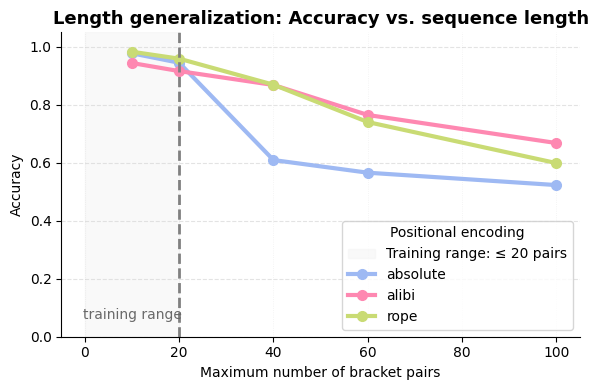

In [23]:
pes = length_results["positional_embedding"].sort_values().unique()

palette = px.colors.qualitative.Pastel[5:]
palette = [rgb_string_to_tuple(c) for c in palette]
colors = palette[:len(pes)]

plt.figure(figsize=(6, 4))

plt.axvspan(
    0,
    TRAIN_MAX_PAIRS,
    alpha=0.12,
    color="lightgray",
    label=f"Training range: ≤ {TRAIN_MAX_PAIRS} pairs"
)

for pe, color in zip(pes, colors):
    subset = (
        length_results[length_results["positional_embedding"] == pe]
        .sort_values("max_pairs")
    )

    plt.plot(
        subset["max_pairs"],
        subset["accuracy"],
        marker="o",
        linewidth=3,
        markersize=7,
        label=pe,
        color=color
    )

plt.axvline(
    x=TRAIN_MAX_PAIRS,
    linestyle="--",
    linewidth=2,
    color="gray"
)

plt.text(
    TRAIN_MAX_PAIRS / 2,
    0.05,
    "training range",
    ha="center",
    va="bottom",
    color="dimgray"
)

plt.xlabel("Maximum number of bracket pairs")
plt.ylabel("Accuracy")
plt.title("Length generalization: Accuracy vs. sequence length",
              fontsize=13,
    fontweight="bold",)

plt.legend(title="Positional encoding")

ax = plt.gca()
ax.set_axisbelow(True)
ax.grid(True, axis="y", linestyle="--", linewidth=0.8, alpha=0.35)
ax.grid(True, axis="x", linestyle=":", linewidth=0.6, alpha=0.18)

plt.ylim(0, 1.05)

sns.despine()
plt.tight_layout()
plt.show()

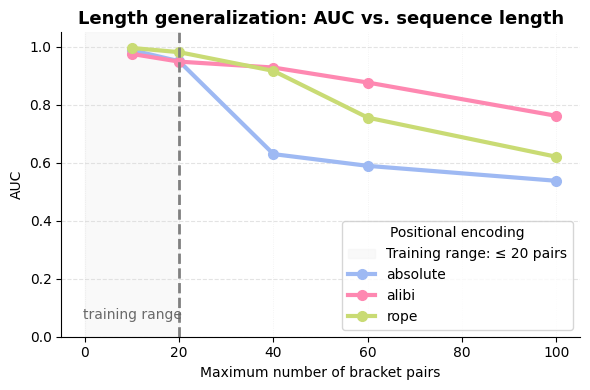

In [22]:
plt.figure(figsize=(6, 4))

plt.axvspan(
    0,
    TRAIN_MAX_PAIRS,
    alpha=0.12,
    color="lightgray",
    label=f"Training range: ≤ {TRAIN_MAX_PAIRS} pairs"
)

for pe, color in zip(pes, colors):
    subset = (
        length_results[length_results["positional_embedding"] == pe]
        .sort_values("max_pairs")
    )

    plt.plot(
        subset["max_pairs"],
        subset["auc"],
        marker="o",
        linewidth=3,
        markersize=7,
        label=pe,
        color=color
    )

plt.axvline(
    x=TRAIN_MAX_PAIRS,
    linestyle="--",
    linewidth=2,
    color="gray"
)

plt.text(
    TRAIN_MAX_PAIRS / 2,
    0.05,
    "training range",
    ha="center",
    va="bottom",
    color="dimgray"
)

plt.xlabel("Maximum number of bracket pairs")
plt.ylabel("AUC")
plt.title("Length generalization: AUC vs. sequence length",
              fontsize=13,
    fontweight="bold",)

plt.legend(title="Positional encoding")

ax = plt.gca()
ax.set_axisbelow(True)
ax.grid(True, axis="y", linestyle="--", linewidth=0.8, alpha=0.35)
ax.grid(True, axis="x", linestyle=":", linewidth=0.6, alpha=0.18)

plt.ylim(0, 1.05)

sns.despine()
plt.tight_layout()
plt.show()

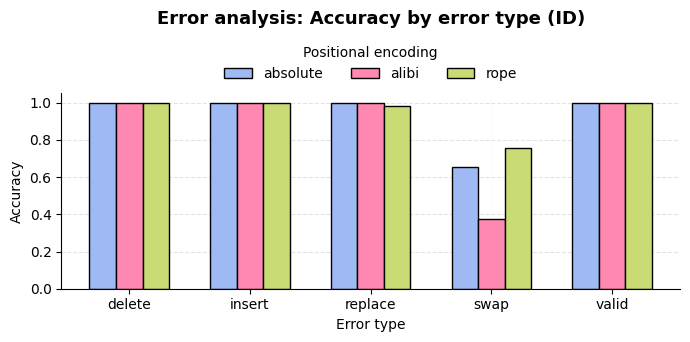

In [30]:
error_type_summary_id = (
    error_df[error_df["test"].isin(["ID_10", "ID_20"])]
    .groupby(["positional_embedding", "error_type"])["correct"]
    .mean()
    .reset_index()
)

pes = error_type_summary_id["positional_embedding"].sort_values().unique()

palette = px.colors.qualitative.Pastel[5:]
palette = [rgb_string_to_tuple(c) for c in palette]
colors = palette[:len(pes)]

error_types = error_type_summary_id["error_type"].unique()
x = range(len(error_types))
bar_width = 0.22

plt.figure(figsize=(7, 4))

for i, (pe, color) in enumerate(zip(pes, colors)):
    subset = (
        error_type_summary_id[
            error_type_summary_id["positional_embedding"] == pe
        ]
        .set_index("error_type")
        .reindex(error_types)
        .reset_index()
    )

    positions = [pos + i * bar_width for pos in x]

    plt.bar(
        positions,
        subset["correct"],
        width=bar_width,
        label=pe,
        color=color,
        edgecolor="black",
        linewidth=1
    )

center_positions = [
    pos + bar_width * (len(pes) - 1) / 2
    for pos in x
]

plt.xticks(center_positions, error_types, rotation=0)

plt.xlabel("Error type")
plt.ylabel("Accuracy")
plt.title(
    "Error analysis: Accuracy by error type (ID)",
    fontsize=13,
    fontweight="bold",
    pad=50
)

plt.legend(
    title="Positional encoding",
    loc="lower center",
    bbox_to_anchor=(0.5, 1.0),
    ncol=len(pes),
    frameon=False
)

ax = plt.gca()
ax.set_axisbelow(True)
ax.grid(True, axis="y", linestyle="--", linewidth=0.8, alpha=0.35)
ax.grid(True, axis="x", linestyle=":", linewidth=0.6, alpha=0.18)

plt.ylim(0, 1.05)

sns.despine()
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig("bar_id.png", dpi=300, bbox_inches="tight")
plt.show()

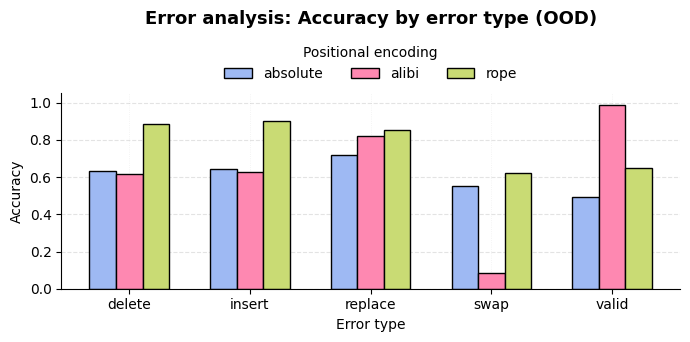

In [31]:
error_type_summary_ood = (
    error_df[error_df["test"].isin(["OOD_40", "OOD_60", "OOD_100"])]
    .groupby(["positional_embedding", "error_type"])["correct"]
    .mean()
    .reset_index()
)

pes = error_type_summary_ood["positional_embedding"].sort_values().unique()

palette = px.colors.qualitative.Pastel[5:]
palette = [rgb_string_to_tuple(c) for c in palette]
colors = palette[:len(pes)]

error_types = error_type_summary_ood["error_type"].unique()
x = range(len(error_types))
bar_width = 0.22

plt.figure(figsize=(7, 4))

for i, (pe, color) in enumerate(zip(pes, colors)):
    subset = (
        error_type_summary_ood[
            error_type_summary_ood["positional_embedding"] == pe
        ]
        .set_index("error_type")
        .reindex(error_types)
        .reset_index()
    )

    positions = [pos + i * bar_width for pos in x]

    plt.bar(
        positions,
        subset["correct"],
        width=bar_width,
        label=pe,
        color=color,
        edgecolor="black",
        linewidth=1
    )

center_positions = [
    pos + bar_width * (len(pes) - 1) / 2
    for pos in x
]

plt.xticks(center_positions, error_types, rotation=0)

plt.xlabel("Error type")
plt.ylabel("Accuracy")
plt.title(
    "Error analysis: Accuracy by error type (OOD)",
    fontsize=13,
    fontweight="bold",
    pad=50
)

plt.legend(
    title="Positional encoding",
    loc="lower center",
    bbox_to_anchor=(0.5, 1.0),
    ncol=len(pes),
    frameon=False
)

ax = plt.gca()
ax.set_axisbelow(True)
ax.grid(True, axis="y", linestyle="--", linewidth=0.8, alpha=0.35)
ax.grid(True, axis="x", linestyle=":", linewidth=0.6, alpha=0.18)

plt.ylim(0, 1.05)

sns.despine()
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig("bar_ood.png", dpi=300, bbox_inches="tight")
plt.show()

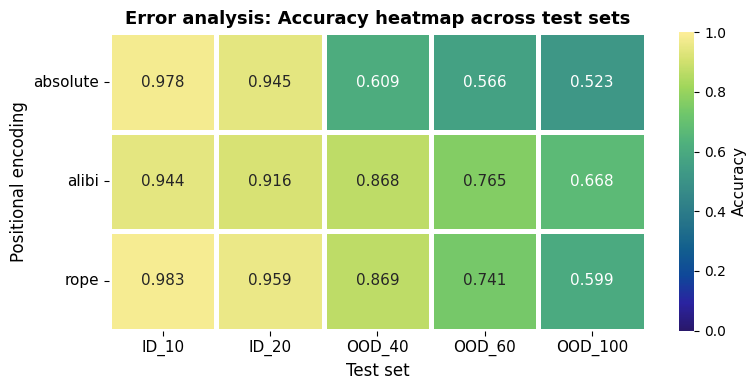

In [28]:
pivot_acc = error_df.pivot_table(
    index="positional_embedding",
    columns="test",
    values="correct",
    aggfunc="mean"
)

test_order = ["ID_10", "ID_20", "OOD_40", "OOD_60", "OOD_100"]
test_order = [t for t in test_order if t in pivot_acc.columns]
pivot_acc = pivot_acc[test_order]

plotly_colors = px.colors.sequential.haline

plotly_colors_hex = [
    mcolors.to_hex(tuple(int(v.strip()) / 255 for v in c[4:-1].split(",")))
    if c.startswith("rgb")
    else c
    for c in plotly_colors
]

plotly_cmap = LinearSegmentedColormap.from_list(
    "plotly_cmap",
    plotly_colors_hex
)

plt.figure(figsize=(8, 4))

ax = sns.heatmap(
    pivot_acc,
    cmap=plotly_cmap,
    annot=True,
    fmt=".3f",
    annot_kws={"fontsize": 11},
    vmin=0,
    vmax=1,
    linewidths=2.5,
    linecolor="white",
    cbar_kws={"label": "Accuracy"}
)

plt.xticks(fontsize=11, rotation=0)
plt.yticks(fontsize=11, rotation=0)

plt.xlabel("Test set", fontsize=12)
plt.ylabel("Positional encoding", fontsize=12)
plt.title(
    "Error analysis: Accuracy heatmap across test sets",
    fontsize=13,
    fontweight="bold"
)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
cbar.set_label("Accuracy", fontsize=11)

plt.tight_layout()
plt.show()

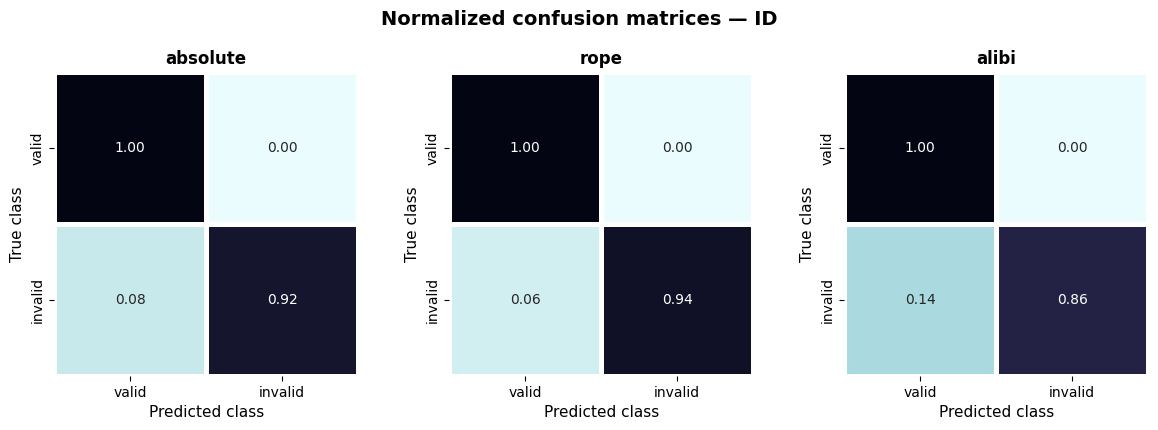

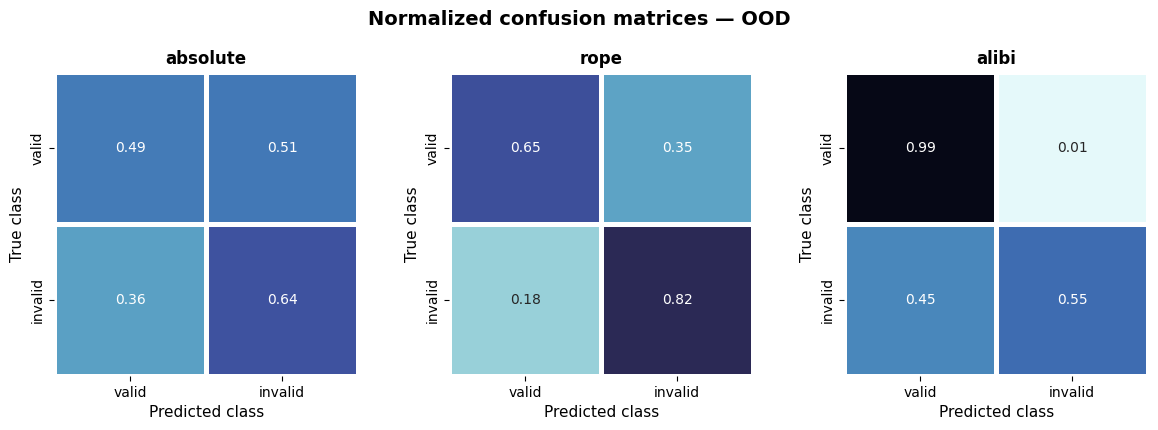

In [18]:
plotly_colors = px.colors.sequential.ice_r

plotly_colors_hex = [
    mcolors.to_hex(tuple(int(v.strip()) / 255 for v in c[4:-1].split(",")))
    if isinstance(c, str) and c.startswith("rgb")
    else c
    for c in plotly_colors
]

plotly_cmap = LinearSegmentedColormap.from_list(
    "plotly_cmap",
    plotly_colors_hex
)


def plot_confusion_matrices_by_group(error_df, group_name, tests):
    subset_group = error_df[error_df["test"].isin(tests)]

    pes = subset_group["positional_embedding"].unique()

    fig, axes = plt.subplots(
        1,
        len(pes),
        figsize=(4 * len(pes), 4)
    )

    if len(pes) == 1:
        axes = [axes]

    for ax, pe in zip(axes, pes):
        subset = subset_group[
            subset_group["positional_embedding"] == pe
        ]

        cm = confusion_matrix(
            subset["label"],
            subset["pred"],
            labels=[0, 1],
            normalize="true"
        )

        sns.heatmap(
            cm,
            annot=True,
            fmt=".2f",
            cmap=plotly_cmap,
            cbar=False,
            square=True,
            linewidths=2.5,
            linecolor="white",
            xticklabels=["valid", "invalid"],
            yticklabels=["valid", "invalid"],
            vmin=0,
            vmax=1,
            ax=ax
        )

        ax.set_title(f"{pe}", fontsize=12, fontweight="bold")
        ax.set_xlabel("Predicted class", fontsize=11)
        ax.set_ylabel("True class", fontsize=11)

    plt.suptitle(
        f"Normalized confusion matrices — {group_name}",
        fontsize=14,
        fontweight="bold",
        y=1.02
    )

    plt.tight_layout()
    plt.show()


plot_confusion_matrices_by_group(
    error_df=error_df,
    group_name="ID",
    tests=["ID_10", "ID_20"]
)

plot_confusion_matrices_by_group(
    error_df=error_df,
    group_name="OOD",
    tests=["OOD_40", "OOD_60", "OOD_100"]
)

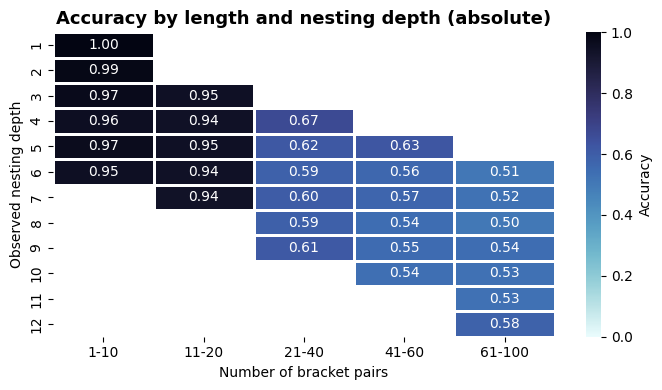

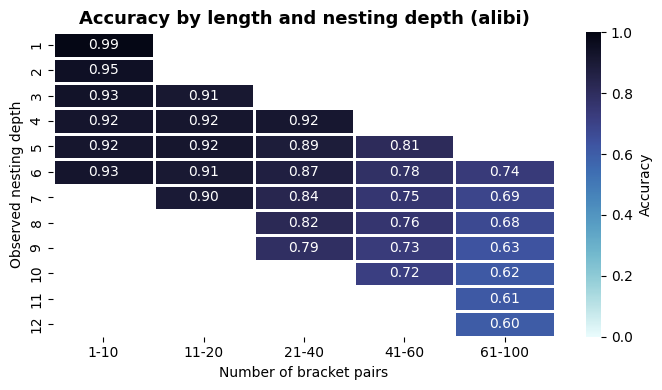

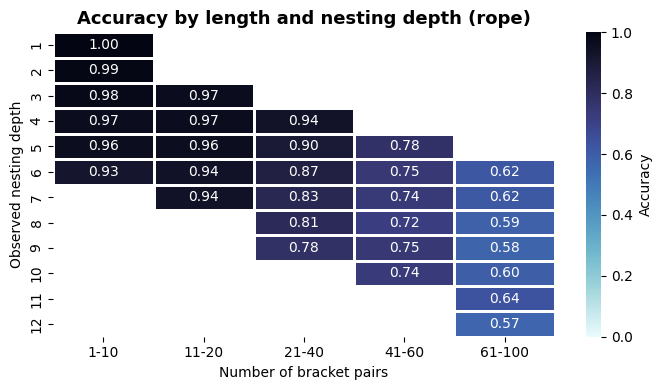

In [19]:
MIN_SAMPLES = 100

error_df["pair_bin"] = pd.cut(
    error_df["num_pairs"],
    bins=[0, 10, 20, 40, 60, 100],
    labels=["1-10", "11-20", "21-40", "41-60", "61-100"],
    include_lowest=True
)

cell_summary = (
    error_df
    .groupby(
        ["positional_embedding", "pair_bin", "observed_depth"],
        observed=False
    )
    .agg(
        accuracy=("correct", "mean"),
        n=("correct", "size")
    )
    .reset_index()
)

# odfiltruj bunky s malým počtom príkladov
cell_summary.loc[cell_summary["n"] < MIN_SAMPLES, "accuracy"] = None

plotly_colors = px.colors.sequential.ice_r

plotly_colors_hex = [
    mcolors.to_hex(tuple(int(v.strip()) / 255 for v in c[4:-1].split(",")))
    if isinstance(c, str) and c.startswith("rgb")
    else c
    for c in plotly_colors
]

plotly_cmap = LinearSegmentedColormap.from_list(
    "plotly_cmap",
    plotly_colors_hex
)

for pe in cell_summary["positional_embedding"].unique():
    subset = cell_summary[cell_summary["positional_embedding"] == pe]

    pivot_acc = subset.pivot_table(
        index="observed_depth",
        columns="pair_bin",
        values="accuracy",
        aggfunc="mean",
        observed=False
    )

    plt.figure(figsize=(7, 4))

    ax = sns.heatmap(
        pivot_acc,
        cmap=plotly_cmap,
        annot=True,
        fmt=".2f",
        vmin=0,
        vmax=1,
        linewidths=2,
        linecolor="white",
        cbar_kws={"label": "Accuracy"}
    )

    plt.xlabel("Number of bracket pairs")
    plt.ylabel("Observed nesting depth")
    plt.title(
        f"Accuracy by length and nesting depth ({pe})",
        fontsize=13,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()